Mackey-Glass task using Echo State Network

## Training

In [1]:
## Defining the network and the update rule
import numpy as np
from numpy.linalg import eigvals
from numpy import typing as npt
from typing import Annotated, Literal
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=42)

N = 400 #internal units
K = 1   #input units
L = 1   #output units

#Weights. N internal units. 1 input unit. 1 output unit.


W = rng.choice([0,0.4,-0.4],size=[N,N],p=[0.9875,0.00625,0.00625])

eigval = eigvals(W)
W = (0.79/max(abs(eigval)))*W
eigval = eigvals(W)
print('|lambda_max| =',max(abs(eigval)))


W_in = rng.choice([0,0.14,-0.14],size=[N,K],p=[0.5,0.25,0.25])



W_back = rng.choice([0,0.56,-0.56],size=[N,L])


# Update rule
def update(x:Annotated[npt.NDArray[np.float64], Literal["N","M"]],u:npt.NDArray[np.float64],y:npt.NDArray[np.float64],delta=1,C=0.44,a=0.9) -> npt.NDArray[np.float64]:
    x = (1-delta*C*a)*x + delta*C*(np.tanh(W_in @ u + W @ x + W_back @ y))
    return x 

#Output
def output(W_out:npt.NDArray[np.float64],x:npt.NDArray[np.float64],u:npt.NDArray[np.float64],y:npt.NDArray[np.float64],f) -> npt.NDArray[np.float64]:
    a = np.concatenate((x,u,y),axis=0)
    y_out = f(W_out @ a)
    return y_out
 


|lambda_max| = 0.7900000000000035


In [2]:
def MG_series(length,tau_MG):
    sigma, steps = 0.1, (length+1000)*10
    A = np.zeros(steps)
    A[0] = 1.2
    delay_idx = int(tau_MG / sigma)

    for i in range(steps - 1):
        # Using 1.2 as history to avoid the fixed-point at 0
        delayed_val = A[i - delay_idx] if i >= delay_idx else 1.2
        A[i+1] = A[i] + sigma * ((0.2 * delayed_val) / (1 + delayed_val**10) - 0.1 * A[i])

    # Subsample and shift data for the task
    return A[10000::10]

## Subsample after washout
y_original = MG_series(3000,17)
print(np.min(y_original), np.max(y_original))
y = np.tanh(y_original-1)
print(np.min(y), np.max(y))

0.4121413478914421 1.3223447306227571
-0.528353780188347 0.3116254981017158


In [3]:
## Algorithm
x = np.random.uniform(-1,1,[N,1])
y = np.reshape(y,(len(y),-1))
u = np.array([[0.2]])

#Washout (1000 steps)
for i in range(1000):
    x = update(x,u.reshape(1,-1),y[i].reshape(1,-1))
    # Now we are at x(1001)

#Training
X = np.zeros([2000,N])  #Collects x(1002) to x(3000)
X[0,:] = x[:,0]
for i in range(1000,2999):   #total 2000 steps
    x = update(x,u.reshape(1,-1),y[i].reshape(1,-1))
    X[i-999,:] = x[:,0]



In [4]:
from sklearn.linear_model import LinearRegression, Ridge
model = LinearRegression(fit_intercept=False)
#model = Ridge(alpha=1e-5).fit(X,y[-2000:])
model.fit(X,y[-2000:])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


[[ 94  70 163 219]
 [371 350 332 244]
 [389 249 271  55]]


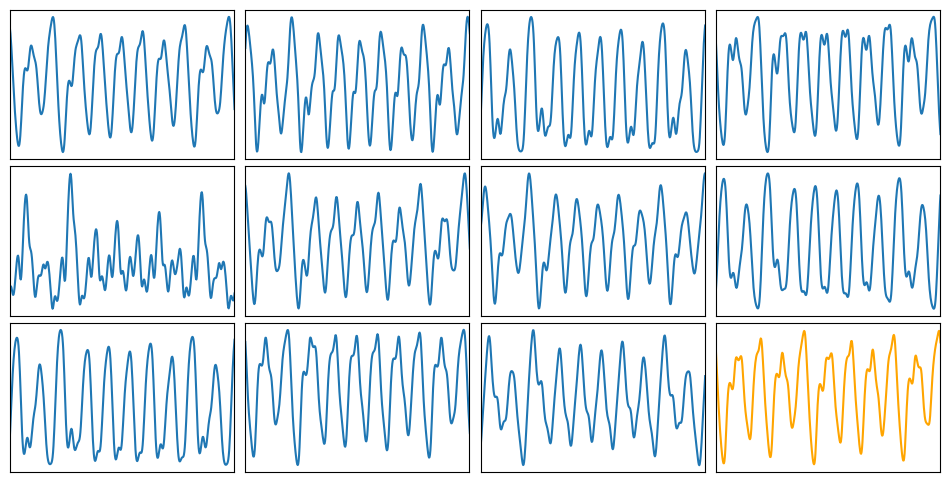

In [5]:
# Plotting the internal units during the training period
fig, ax = plt.subplots(3,4,figsize=(12,6), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
unit_idx = rng.choice(400,size=[3,4])
print(unit_idx)
for i in range(3):
    for j in range(4):
        if [i,j] == [2,3]: 
            ax[i,j].plot(y,color='orange')
            ax[i,j].set_xlim(0,500)
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
            continue
        ax[i,j].plot(X[:,unit_idx[i,j]])
        ax[i,j].set_xlim(0,500)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

Text(0, 0.5, 'weight value')

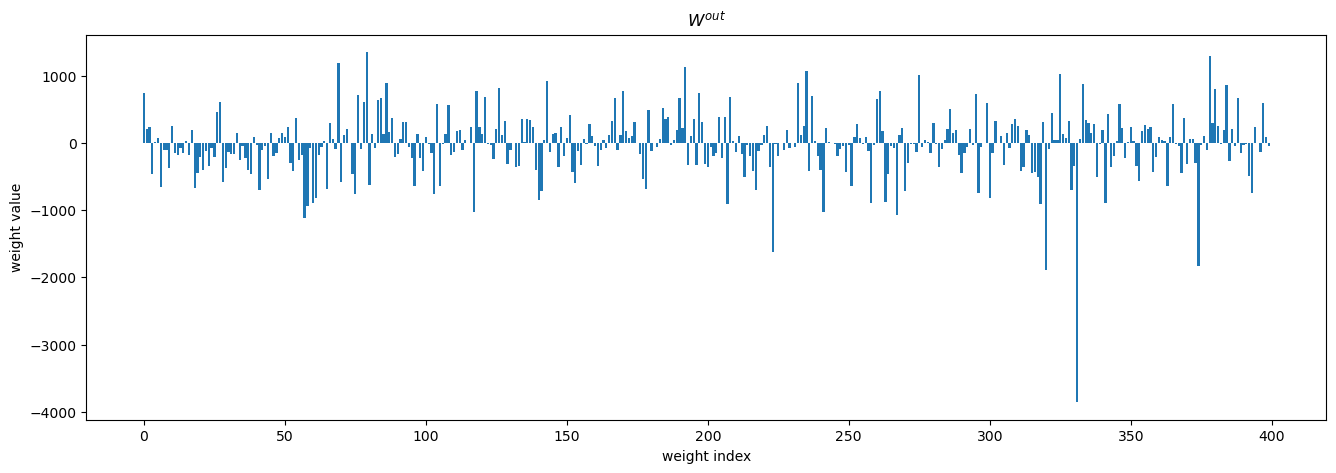

In [6]:
## Plotting the trained output weights
A = np.array(model.coef_)
index = [i for i in range(N)]
plt.figure(figsize=(16,5))
plt.bar(index,A[0])
plt.title(r'$W^{out}$')
plt.xlabel('weight index')
plt.ylabel('weight value')
#plt.ylim(-500,500)

In [7]:
#mse train
y_out = model.predict(X)
mse = np.mean((y[-2000:]-y_out)**2)
print('mse =', mse)

mse = 5.644939621314908e-12


In [8]:
print(model.coef_.shape)
print(model.intercept_)
W_out = model.coef_

(1, 400)
0.0


## Testing

In [9]:
## Test data
sigma = 1/10
tau_MG = 17
discard = 1000
test = 4000

A = np.zeros((discard+test)*10)
A[0] = 1.2
for i in range(0,len(A)-1):
    A[i+1] = A[i] + sigma*((0.2*A[i-int(tau_MG/sigma)])/(1 + A[i - int(tau_MG/sigma)]**10) - 0.1*A[i])

## Subsample after washout
A = A[discard*10:]
y_original = np.zeros(test)
for i in range(len(y_original)):
    y_original[i] = A[i*10]
print(np.min(y_original), np.max(y_original))
y = np.tanh(y_original-1)
print(np.min(y), np.max(y))

0.41227450651862435 1.3224333377547517
-0.5282577870665173 0.3117054983459592


In [10]:
## Testing phase
x = np.random.uniform(-1,1,[N,1])
for i in range(1000):
    x = update(x,u.reshape(1,-1),y[i].reshape(1,-1))
    # now we are at x(1001)

y_pred = np.zeros(3000)
y_pred[0] = model.predict(x.reshape(1,-1))[0][0]  #This corresponds to y(1001)
for i in range(2999):   #This takes x(1001) to x(3000)
    x = update(x,u.reshape(1,-1),y_pred[i].reshape(1,-1))
    y_pred[i+1] = model.predict(x.reshape(1,-1))[0][0]

(0.0, 1000.0)

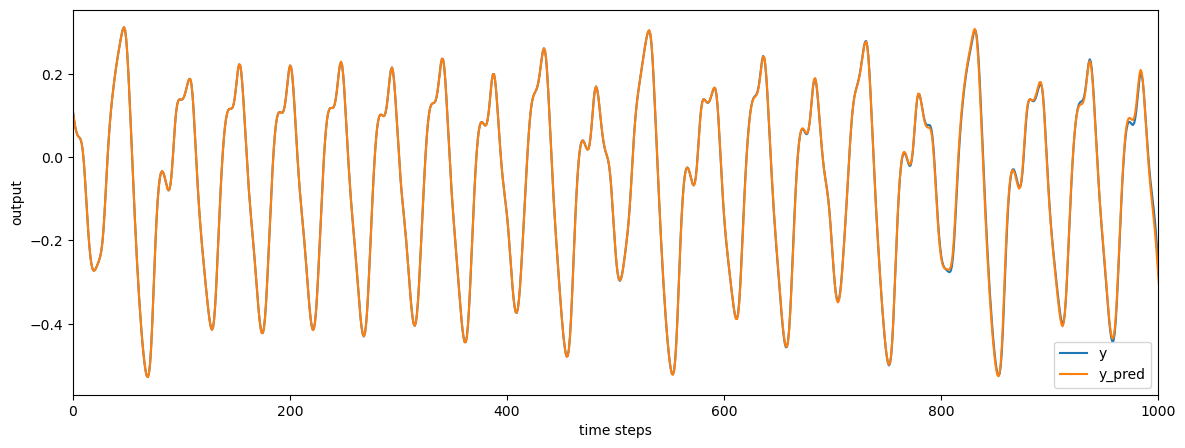

In [11]:
plt.figure(figsize=(14,5))
plt.plot(y[-3000:],label='y')
plt.plot(y_pred,label='y_pred')
plt.legend()
plt.xlabel('time steps')
plt.ylabel('output')
plt.xlim(0,1000)

In [12]:
# mse
mse_test = np.mean((y[-3000:]-y_pred)**2)
print('mse_test =', mse_test)

mse_test = 0.012954271183848218


Text(0.5, 1.0, 'Predicted attractor')

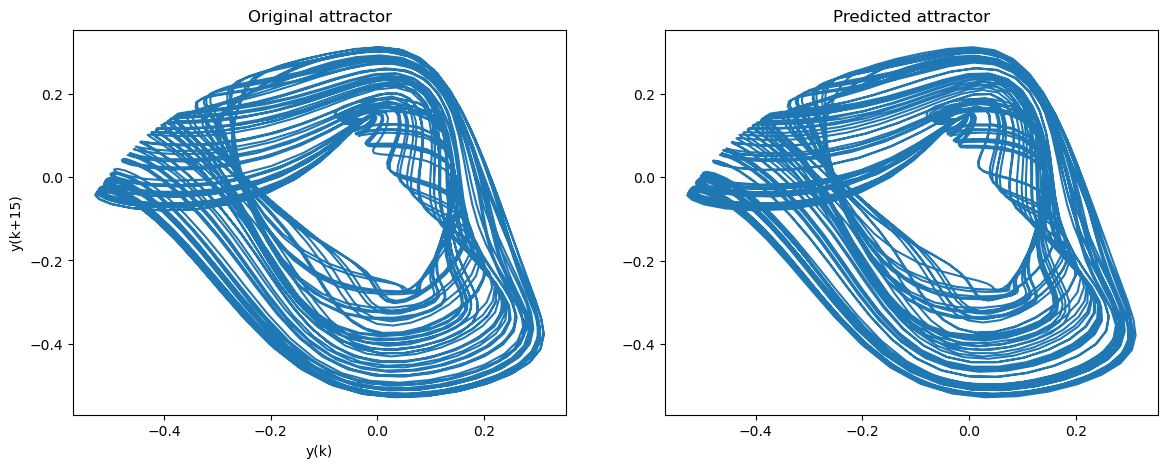

In [13]:
## Attractor
figure, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(y[1000:3985],y[1015:])
axes[0].set_title('Original attractor')
axes[0].set_xlabel('y(k)')
axes[0].set_ylabel('y(k+15)')
axes[1].plot(y_pred[:2985],y_pred[15:])
axes[1].set_title('Predicted attractor')
